## Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights

**Objective**: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.


In [4]:
#!pip install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
%matplotlib inline
pd.set_option('display.max_columns', None)
# Download latest version
#path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

#print("Path to dataset files:", path)

### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

In [11]:
import pandas as pd

# Load the dataset from your local path
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

freq_df = (
    df['category']
    .value_counts()                          # count occurrences, sorted descending
    .rename_axis('category')                 # name the index column
    .reset_index(name='count')               # convert index to a column called 'count'
    .assign(
        percentage    = lambda x: (x['count'] / x['count'].sum() * 100).round(2),
        cumulative_pct= lambda x: x['percentage'].cumsum().round(2)  # running total %
    )
)

# Top 5 most listed categories
top_5 = freq_df.head(5)
print("Top 5 Most Listed Product Categories:")
print(top_5.to_string(index=False))  # cleaner print without row index

# How much of the dataset do top 5 cover?
print(f"\nTop 5 categories cover {top_5['percentage'].sum():.2f}% of all listings")

Top 5 Most Listed Product Categories:
                              category  count  percentage  cumulative_pct
                     Sports & Outdoors 836265       34.22           34.22
                                Beauty  19312        0.79           35.01
Handmade Clothing, Shoes & Accessories  19229        0.79           35.80
                           Bath & Body  19092        0.78           36.58
                        Birthday Gifts  18978        0.78           37.36

Top 5 categories cover 37.36% of all listings


Columns: ['category', 'count']
                                 category   count
0                       Sports & Outdoors  836265
1                                  Beauty   19312
2  Handmade Clothing, Shoes & Accessories   19229
3                             Bath & Body   19092
4                          Birthday Gifts   18978


C:\Users\KaoticCharma\AppData\Local\Temp\ipykernel_4040\1782127696.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


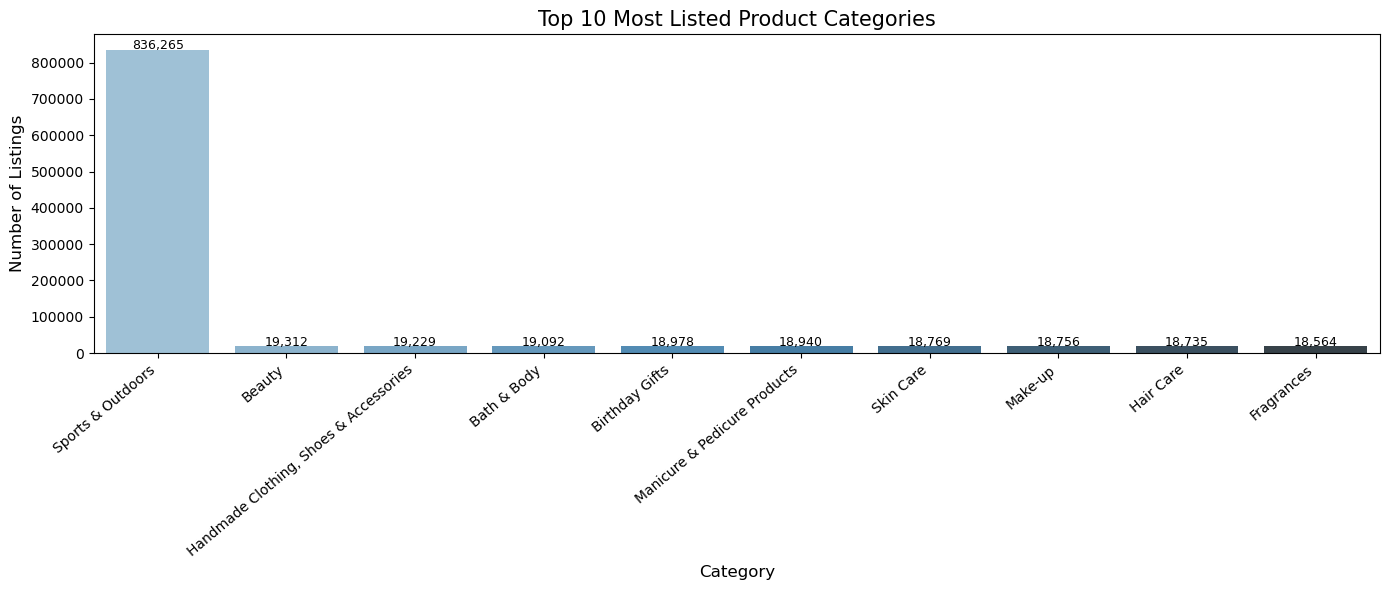

In [20]:
# Prepare top 10 as a DataFrame for seaborn compatibility
df

top_10 = (
    df['category'].value_counts()
    .head(10)
    .reset_index()
    #.rename(columns={'index': 'category', 'category': 'count'})  # fix column names
)

print("Columns:", top_10.columns.tolist())
print(top_10.head())

# --- BAR CHART with Seaborn ---
plt.figure(figsize=(14, 6))
sns.barplot(
    data=top_10,
    x='category', y='count',
    palette='Blues_d'          # gradient color palette
)
plt.title('Top 10 Most Listed Product Categories', fontsize=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.xticks(rotation=40, ha='right')

# Annotate each bar with its count value
for i, row in top_10.iterrows():
    plt.text(i, row['count'] + 500, f"{row['count']:,}",
             ha='center', fontsize=9)  # place text slightly above each bar

plt.tight_layout()
plt.show()


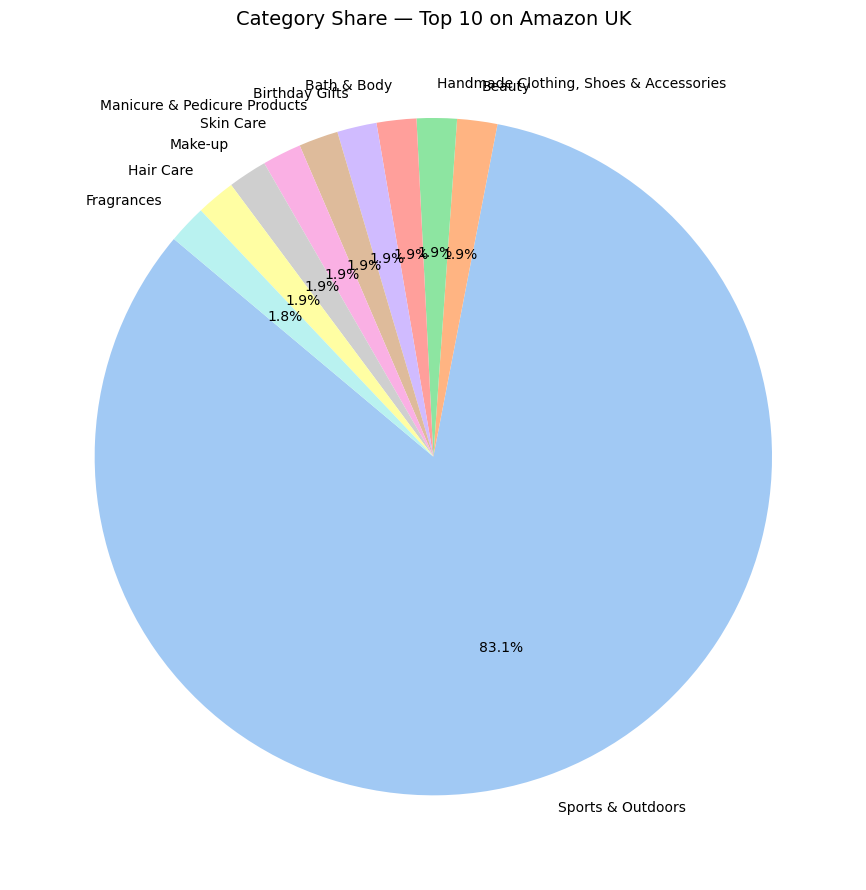

In [19]:
# --- PIE CHART ---
plt.figure(figsize=(9, 9))
plt.pie(
    top_10['count'],
    labels=top_10['category'],
    autopct='%1.1f%%',          # show % on each slice
    startangle=140,             # rotate starting angle for better label placement
    colors=sns.color_palette('pastel', len(top_10))  # soft pastel colors
)
plt.title('Category Share — Top 10 on Amazon UK', fontsize=14)
plt.tight_layout()
plt.show()

### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 

In [21]:
# Question 2.1 — Measures of Centrality (Mean, Median, Mode)

# Drop NaN prices before calculating — avoids misleading results
price = df['price'].dropna()

mean_price   = price.mean()
median_price = price.median()
mode_price   = price.mode()[0]  # mode() can return multiple values; take the first

# Build a summary DataFrame for clean display
centrality_df = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Mode'],
    'Value (£)': [round(mean_price, 2), round(median_price, 2), round(mode_price, 2)]
})

print(centrality_df.to_string(index=False))

# Business interpretation
print(f"\n📌 Mean is £{mean_price - median_price:.2f} higher than the Median.")
print("   This gap suggests the presence of high-priced outliers skewing the average upward.")


Metric  Value (£)
  Mean      89.24
Median      19.09
  Mode       9.99

📌 Mean is £70.15 higher than the Median.
   This gap suggests the presence of high-priced outliers skewing the average upward.


In [22]:
# Question 2.2 — Measures of Dispersion (Variance, Std Dev, Range, IQR)

price = df['price'].dropna()
price = price[price > 0]

Q1  = price.quantile(0.25)
Q3  = price.quantile(0.75)
IQR = Q3 - Q1

# Outlier boundaries using the standard 1.5×IQR rule
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count how many products fall outside the outlier boundaries
outliers = price[(price < lower_bound) | (price > upper_bound)]

dispersion_df = pd.DataFrame({
    'Metric'  : ['Variance', 'Std Dev', 'Min', 'Max', 'Range', 'Q1', 'Q3', 'IQR',
                 'Lower Fence', 'Upper Fence', 'Outlier Count'],
    'Value (£)': [
        round(price.var(), 2),
        round(price.std(), 2),
        round(price.min(), 2),
        round(price.max(), 2),
        round(price.max() - price.min(), 2),
        round(Q1, 2),
        round(Q3, 2),
        round(IQR, 2),
        round(lower_bound, 2),
        round(upper_bound, 2),
        len(outliers)
    ]
})

print(dispersion_df.to_string(index=False))
print(f"\n⚠️  {len(outliers):,} outlier products ({len(outliers)/len(price)*100:.1f}% of listings)")

       Metric  Value (£)
     Variance  119446.40
      Std Dev     345.61
          Min       0.01
          Max  100000.00
        Range   99999.99
           Q1       9.99
           Q3      45.99
          IQR      36.00
  Lower Fence     -44.01
  Upper Fence      99.99
Outlier Count  327688.00

⚠️  327,688 outlier products (13.4% of listings)


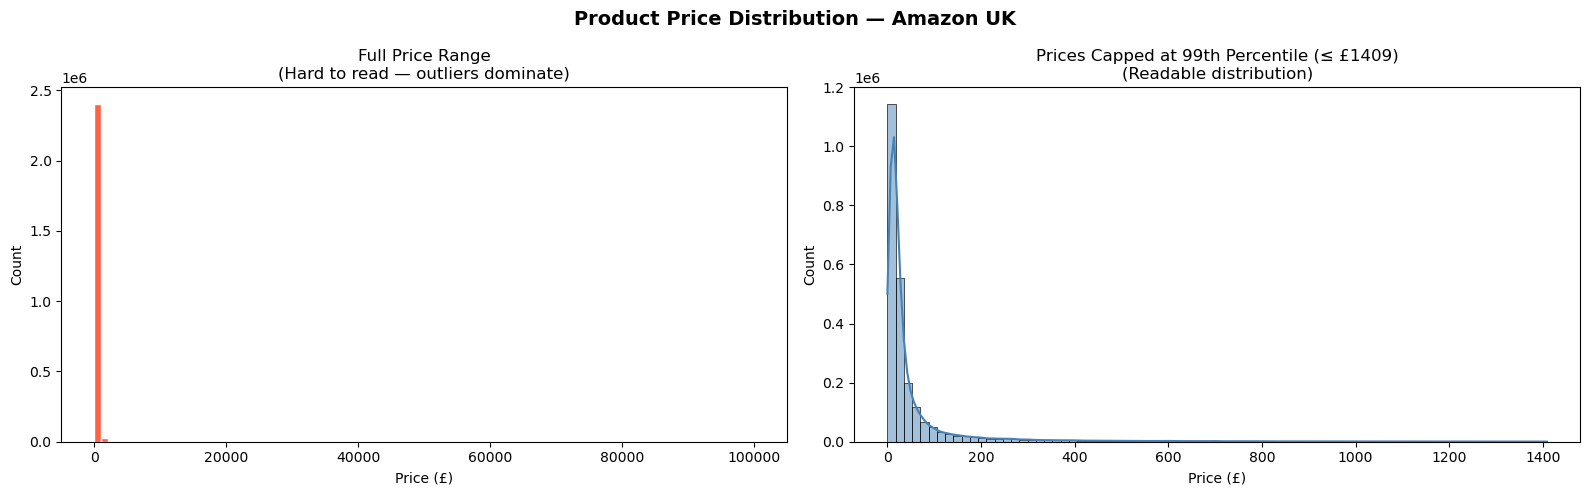

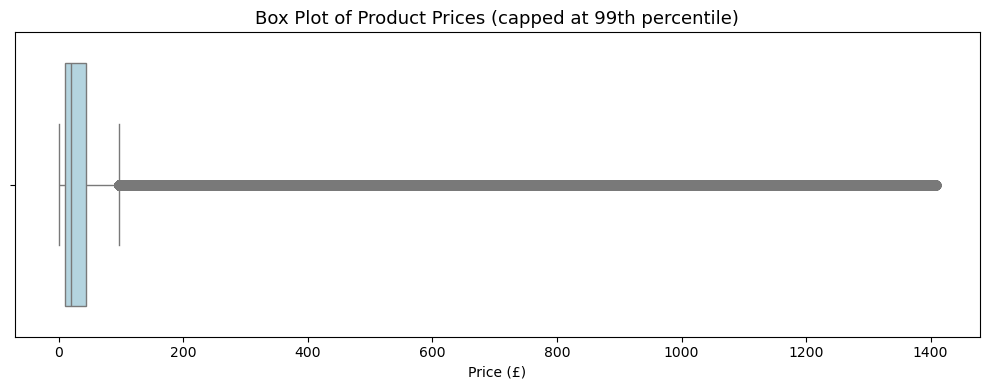

In [23]:
# Question 2.3 — Visualizations (Histogram & Box Plot)

price = df['price'].dropna()
price = price[price > 0]

# Cap at 99th percentile to remove extreme outliers for visualization
# This preserves 99% of data while making the chart readable
cap   = price.quantile(0.99)
price_capped = price[price <= cap]

# --- HISTOGRAM with KDE overlay ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: raw (uncapped) — shows why outliers are a problem
axes[0].hist(price, bins=100, color='tomato', edgecolor='white')
axes[0].set_title('Full Price Range\n(Hard to read — outliers dominate)')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Count')

# Right: capped at 99th percentile — shows the real distribution
sns.histplot(price_capped, bins=80, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title(f'Prices Capped at 99th Percentile (≤ £{cap:.0f})\n(Readable distribution)')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Count')

plt.suptitle('Product Price Distribution — Amazon UK', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- BOX PLOT ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=price_capped, color='lightblue')
plt.title('Box Plot of Product Prices (capped at 99th percentile)', fontsize=13)
plt.xlabel('Price (£)')
plt.tight_layout()
plt.show()


### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

In [24]:
# Question 3.1 — Measures of Centrality (Mean, Median, Mode)

stars = df['stars'].dropna()

# Stars are on a fixed scale (0.0 – 5.0), so valid range check matters
# Ratings outside this range are data errors
stars = stars[(stars >= 0) & (stars <= 5)]

mean_stars   = stars.mean()
median_stars = stars.median()
mode_values  = stars.mode()   # could be multimodal — multiple equally common ratings
mode_stars   = mode_values[0]

# Build a clean summary table
summary = pd.DataFrame({
    'Metric'   : ['Mean', 'Median', 'Mode'],
    'Value (⭐)': [round(mean_stars, 2), round(median_stars, 2), round(mode_stars, 2)]
})

print(summary.to_string(index=False))

# Gap between mean and median tells us about skew direction
gap = mean_stars - median_stars
print(f"\n📌 Mean is {abs(gap):.2f} {'above' if gap > 0 else 'below'} the Median.")
print("   Ratings tend to be skewed toward higher values (positivity bias)." if gap < 0
      else "   Ratings are fairly balanced around the average.")

# Check if multiple modes exist
if len(mode_values) > 1:
    print(f"\n⚠️  Multiple modes: {mode_values.tolist()} — customers cluster at several rating points")

Metric  Value (⭐)
  Mean       2.15
Median       0.00
  Mode       0.00

📌 Mean is 2.15 above the Median.
   Ratings are fairly balanced around the average.


In [27]:
# Question 3.2 — Measures of Dispersion (Variance, Std Dev, IQR)

stars = stars[(stars >= 0) & (stars <= 5)]

Q1  = stars.quantile(0.25)
Q3  = stars.quantile(0.75)
IQR = Q3 - Q1

# Outlier fences using 1.5×IQR rule
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Count ratings flagged as outliers
outliers = stars[(stars < lower_fence) | (stars > upper_fence)]

# Full dispersion table
dispersion_df = pd.DataFrame({
    'Metric'  : ['Variance', 'Std Dev', 'Min', 'Max', 'Q1', 'Q3',
                 'IQR', 'Lower Fence', 'Upper Fence', 'Outlier Count'],
    'Value'   : [
        round(stars.var(), 4),
        round(stars.std(), 4),
        round(stars.min(), 2),
        round(stars.max(), 2),
        round(Q1, 2),
        round(Q3, 2),
        round(IQR, 4),
        round(lower_fence, 2),
        round(upper_fence, 2),
        len(outliers)
    ]
})

print(dispersion_df.to_string(index=False))
print(f"\n⚠️  {len(outliers):,} ratings flagged as outliers ({len(outliers)/len(stars)*100:.2f}% of all ratings)")

       Metric   Value
     Variance  4.8174
      Std Dev  2.1949
          Min  0.0000
          Max  5.0000
           Q1  0.0000
           Q3  4.4000
          IQR  4.4000
  Lower Fence -6.6000
  Upper Fence 11.0000
Outlier Count  0.0000

⚠️  0 ratings flagged as outliers (0.00% of all ratings)


In [34]:
# Question 3.3 — Shape of Distribution (Skewness & Kurtosis)
from scipy import stats
stars = stars[(stars >= 0) & (stars <= 5)]

skewness = stars.skew()
kurtosis = stars.kurt()   # excess kurtosis: 0 = normal, >0 = peaked, <0 = flat

# Pearson's skewness coefficient: alternative measure using mean/median/std
# Useful cross-check — different formula, same concept
pearson_skew = 3 * (stars.mean() - stars.median()) / stars.std()

# D'Agostino K² normality test on a stratified sample
sample = stars.sample(min(5000, len(stars)), random_state=42)
norm_stat, norm_p = stats.normaltest(sample)

# Jarque-Bera test: combines skewness and kurtosis into one normality test
jb_stat, jb_p = stats.jarque_bera(sample)

# Per-category shape analysis — does skewness differ by category?
df_clean = df[df['stars'].notna() & df['category'].notna()]
df_clean = df_clean[(df_clean['stars'] >= 0) & (df_clean['stars'] <= 5)]

category_shape = (
    df_clean.groupby('category')['stars']
    .agg(
        mean     = 'mean',
        skewness = lambda x: x.skew(),   # per-category skewness
        kurtosis = lambda x: x.kurt(),   # per-category kurtosis
        count    = 'count'
    )
    .round(4)
    .sort_values('skewness')             # most negatively skewed first
)

# --- Print global shape summary ---
print("=" * 45)
print("  GLOBAL RATING DISTRIBUTION SHAPE")
print("=" * 45)
print(f"  Skewness (Fisher)   : {skewness:.4f}")
print(f"  Skewness (Pearson)  : {pearson_skew:.4f}")
print(f"  Kurtosis (excess)   : {kurtosis:.4f}")
print(f"  D'Agostino p-value  : {norm_p:.6f}  → {'NOT normal' if norm_p < 0.05 else 'Normal'}")
print(f"  Jarque-Bera p-value : {jb_p:.6f}  → {'NOT normal' if jb_p < 0.05 else 'Normal'}")
print("=" * 45)

# --- Top 5 most and least skewed categories ---
print("\nTop 5 Most Negatively Skewed Categories (ratings lean HIGH):")
print(category_shape.head(5)[['mean', 'skewness', 'kurtosis', 'count']].to_string())

print("\nTop 5 Most Positively Skewed Categories (ratings lean LOW):")
print(category_shape.tail(5)[['mean', 'skewness', 'kurtosis', 'count']].to_string())

  GLOBAL RATING DISTRIBUTION SHAPE
  Skewness (Fisher)   : 0.0812
  Skewness (Pearson)  : 2.9426
  Kurtosis (excess)   : -1.9260
  D'Agostino p-value  : 0.000000  → NOT normal
  Jarque-Bera p-value : 0.000000  → NOT normal

Top 5 Most Negatively Skewed Categories (ratings lean HIGH):
                         mean  skewness  kurtosis  count
category                                                
Customers' Most Loved  4.4100   -8.8150  109.0787   7302
USB Hubs               4.3568   -7.0819   64.8313    250
Grocery                4.4691   -6.9585   74.8537   9564
Arts & Crafts          4.4327   -6.2085   46.9035   9549
Laptop Accessories     4.4496   -6.0384   38.0522    250

Top 5 Most Positively Skewed Categories (ratings lean LOW):
                                          mean  skewness  kurtosis  count
category                                                                 
Motorbike Instruments                   0.1665    4.7859   21.8125   4168
3D Printing & Scanning           

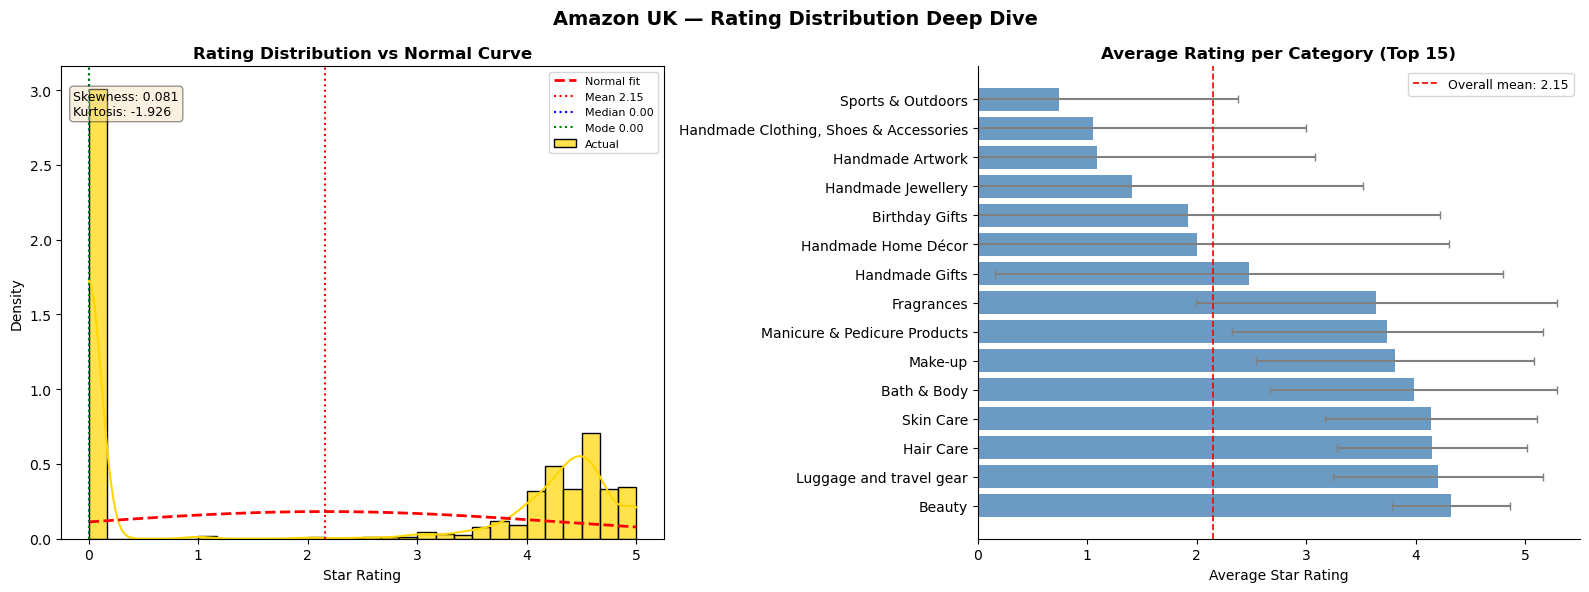

In [35]:
# Question 3.4 — Visualization (Histogram of Ratings)
import matplotlib.ticker as mticker

stars = stars[(stars >= 0) & (stars <= 5)]

mean_s   = stars.mean()
median_s = stars.median()
mode_s   = stars.mode()[0]
skew_s   = stars.skew()
kurt_s   = stars.kurt()

# ============================================================
# FIGURE 1: Histogram + KDE + Normal curve overlay
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Histogram with KDE and fitted normal curve for comparison
ax = axes[0]
sns.histplot(stars, bins=30, kde=True, stat='density',
             ax=ax, color='gold', alpha=0.7, label='Actual')

# Overlay a normal distribution with same mean/std — visual normality check
x   = np.linspace(stars.min(), stars.max(), 300)
pdf = stats.norm.pdf(x, mean_s, stars.std())  # normal PDF with same mean/std
ax.plot(x, pdf, 'r--', linewidth=2, label='Normal fit')

# Reference lines for mean, median, mode
for val, label, color in [
    (mean_s,   f'Mean {mean_s:.2f}',     'red'),
    (median_s, f'Median {median_s:.2f}', 'blue'),
    (mode_s,   f'Mode {mode_s:.2f}',     'green'),
]:
    ax.axvline(val, color=color, linestyle=':', linewidth=1.5, label=label)

ax.set_title('Rating Distribution vs Normal Curve', fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.text(0.02, 0.95,
        f"Skewness: {skew_s:.3f}\nKurtosis: {kurt_s:.3f}",
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# ============================================================
# Right: Per-category average rating heatmap
# ============================================================
ax2 = axes[1]
df_clean = df[df['stars'].notna() & df['category'].notna()]
top_cats = df_clean['category'].value_counts().head(15).index  # top 15 categories

# Rating distribution per category as a pivot
cat_rating = (
    df_clean[df_clean['category'].isin(top_cats)]
    .groupby('category')['stars']
    .agg(['mean', 'std', 'count'])
    .round(2)
    .sort_values('mean', ascending=False)
)

# Plot as horizontal bar chart with error bars (std)
ax2.barh(cat_rating.index, cat_rating['mean'],
         xerr=cat_rating['std'],          # error bars show std dev per category
         color='steelblue', alpha=0.8,
         error_kw=dict(ecolor='gray', capsize=3))
ax2.axvline(mean_s, color='red', linestyle='--',
            linewidth=1.2, label=f'Overall mean: {mean_s:.2f}')
ax2.set_title('Average Rating per Category (Top 15)', fontweight='bold')
ax2.set_xlabel('Average Star Rating')
ax2.set_xlim(0, 5.5)
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Amazon UK — Rating Distribution Deep Dive', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()